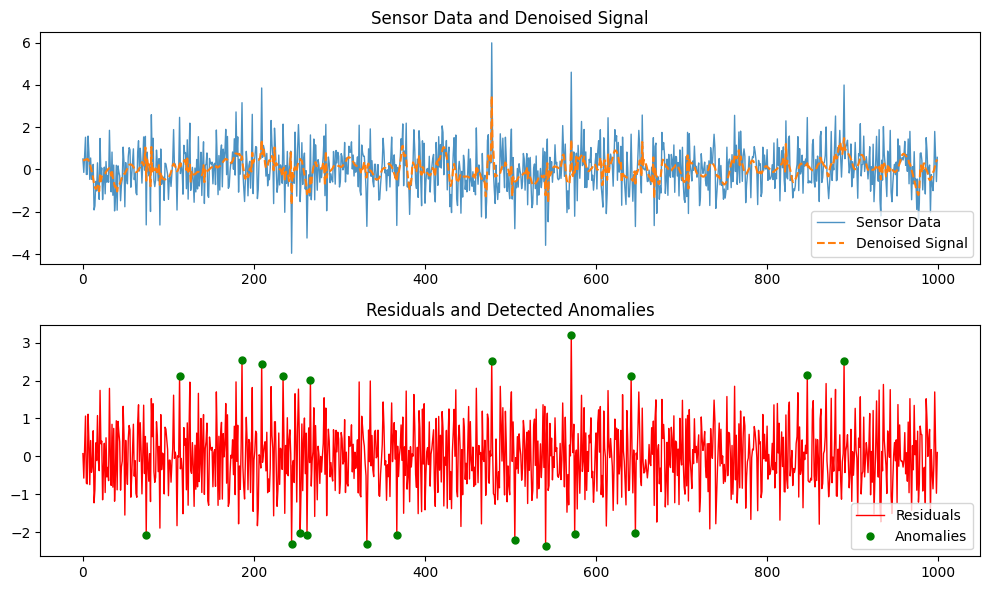

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# 1. Generate synthetic sensor data with random noise and anomalies
np.random.seed(42)
n_samples = 1000
sensor_data = np.random.normal(0, 1, n_samples)

# Insert random anomaly spikes
anomaly_indices = np.random.choice(n_samples, size=25, replace=False)
sensor_data[anomaly_indices] += np.random.choice([-1, 1], size=25) * np.random.uniform(2.2, 3.2, size=25)

# 2. Perform Wavelet Denoising (DWT)
wavelet = 'db4'
level = 3
coeffs = pywt.wavedec(sensor_data, wavelet, level=level)

# Threshold detail coefficients to smooth out noise/spikes
threshold = 1.5 * np.std(coeffs[-1])
coeffs_thresholded = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]

# Reconstruct the denoised baseline signal
denoised_signal = pywt.waverec(coeffs_thresholded, wavelet)[:n_samples]

# 3. Calculate Residuals
residuals = sensor_data - denoised_signal

# 4. Detect Anomalies based on Residual Threshold
residual_threshold = 2.0
anomaly_mask = np.abs(residuals) > residual_threshold
anomaly_x = np.where(anomaly_mask)[0]
anomaly_y = residuals[anomaly_mask]

# 5. Plot Results (Matching expected output)
plt.figure(figsize=(10, 6))

# Subplot 1: Sensor Data and Denoised Signal
plt.subplot(2, 1, 1)
plt.plot(sensor_data, label='Sensor Data', linewidth=1, alpha=0.8)
plt.plot(denoised_signal, label='Denoised Signal', linestyle='--', linewidth=1.5)
plt.title('Sensor Data and Denoised Signal')
plt.legend(loc='lower right')

# Subplot 2: Residuals and Detected Anomalies
plt.subplot(2, 1, 2)
plt.plot(residuals, color='red', label='Residuals', linewidth=1)
plt.plot(anomaly_x, anomaly_y, 'go', label='Anomalies', markersize=5)
plt.title('Residuals and Detected Anomalies')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

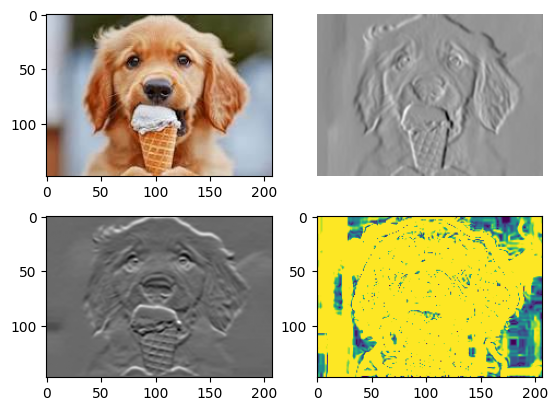

In [ ]:
#EDGE/Boundary Detection
#SOBEL KERNEL
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('/content/dog.jfif')
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(image_rgb,cv2.COLOR_RGB2GRAY)


sobel_x=cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=5)
sobel_y=cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=5)
magnitude=np.sqrt(sobel_x**2 + sobel_y**2)
magnitude=np.uint8(np.clip(magnitude,0,255))
plt.subplot(2,2,1)
plt.imshow(image_rgb)

plt.subplot(2,2,2)
plt.imshow(sobel_x,cmap="gray")
plt.axis("off")
plt.subplot(2,2,3)
plt.imshow(sobel_y,cmap="gray")
plt.subplot(2,2,4)
plt.imshow(magnitude)

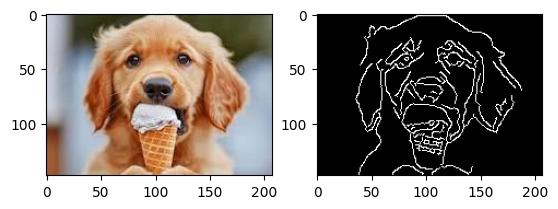

In [ ]:
#CannyEdge Detection
#4steps
#Smoothing(alag se ),CANNY:Gradient,LocalMax(elimnate weak edge),Thresholding(trackin edges)

import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('/content/dog.jfif')
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(image_rgb,cv2.COLOR_RGB2GRAY)

blurred=cv2.GaussianBlur(gray,(5,5),1.4) #1.4 is how much smooth
edges=cv2.Canny(blurred,50,150)#T1 AND T2 50 150 Thresholds

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray") #similiary can show blurred, gray, with cmap



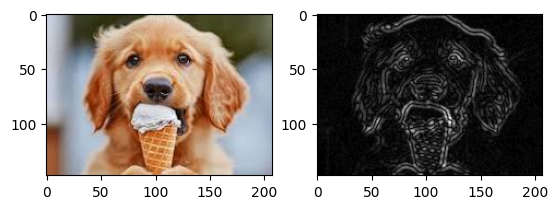

In [ ]:
#Laplacian Of gaussian
# 3 steps: smooth,laplacian(zero-crossing detection)
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('/content/dog.jfif')
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
gray=cv2.cvtColor(image_rgb,cv2.COLOR_RGB2GRAY)
blurred=cv2.GaussianBlur(gray,(5,5),1.4)
laplacian=cv2.Laplacian(blurred,cv2.CV_64F)
laplacian_abs=cv2.convertScaleAbs(laplacian)

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.subplot(1,2,2)
plt.imshow(laplacian_abs,cmap="gray")


In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0) # or give a video path
ret, frame = cap.read()

if ret and frame is not None:
    height, width, channels = frame.shape
    print(f"Width: {width}, Height: {height}")  # e.g., 640 x 480 or 1920 x 1080
else:
    print("Error: Could not read frame. Please check if the camera/video source is available.")

Error: Could not read frame. Please check if the camera/video source is available.


In [11]:
video_path=
cap=cv2.VideoCapture(video_path)
roi_pts=np.array([[100,100],[300,100],[300,300],[100,300]],np.int32)

while cap.isOpened():
  ret,frame=cap.read()
  if not ret:
    cap.set(cv2.CAP_PROP_POS_FRAMES,0)
    continue
    #break


  gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
  blurred=cv2.GaussianBlur(gray,(5,5),4.1)
  edges=cv2.Canny(blurred,50,150)

  #step 1 apply mask to all
  mask=np.zeros_like(edges)
  #make just that portion be all white
  cv2.fillPoly(mask,[roi_pts],255)
  #then put mask on edges
  masked_edges=cv2.bitwise_and(edges,mask)

  cv2.imshow("Security zone boundarises",masked_edges)

 # 5. Extract Contours (Boundaries) within the ROI
  contours, _ = cv2.findContours(
        masked_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
  alarm_triggered = False

    # Check if any detected boundary area exceeds noise threshold
  for cnt in contours:
      if cv2.contourArea(cnt) > 100:  # Ignore tiny edge noise
          alarm_triggered = True

            # Draw the boundary of the unauthorized object
          cv2.drawContours(frame, [cnt], -1, (0, 0, 255), 2)

    # 6. Visualization & Alarm Triggering
  zone_color = (0, 0, 255) if alarm_triggered else (0, 255, 0)
  cv2.polylines(
        frame, [roi_pts], isClosed=True, color=zone_color, thickness=3
    )

  if alarm_triggered:
       cv2.putText(
            frame,
            "ALARM: UNAUTHORIZED OBJECT DETECTED!",
            (50, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2,
        )

    # Display the output feeds
  cv2.imshow("Smart Security System", frame)
  cv2.imshow("Security Zone Boundaries (Masked)", masked_edges)

  # 3. Control playback speed
    # Change 1 to 30 (ms) so 30 FPS video plays at natural real-time speed
  if cv2.waitKey(30) & 0xFF == ord("q"):
     break


cap.release()
cv2.destroyAllWindows()


SyntaxError: invalid syntax (1693481380.py, line 1)

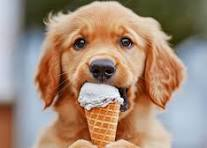

In [13]:
#standard hough line:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/dog.jfif")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# Apply Standard Hough Line Transform
lines = cv2.HoughLines(edges, rho=1, theta=np.pi / 180, threshold=150)

if lines is not None:
    for line in lines:
        rho, theta = line[0]

        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

cv2_imshow(img)

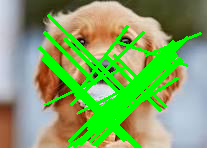

In [15]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/dog.jfif")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# Apply Probabilistic Hough Line Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=40,
    maxLineGap=10,
)

if lines is not None:
    for line in lines:
        # Safely flatten and unpack the coordinates regardless of shape nesting
        x1, y1, x2, y2 = line.ravel()
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

cv2_imshow(img)

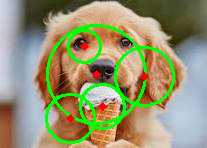

In [17]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/dog.jfif")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray, 5)

# Apply Hough Circle Transform
circles = cv2.HoughCircles(
    blurred,
    method=cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=50,
    param2=30,
    minRadius=10,
    maxRadius=50,
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        x, y, r = circle[0], circle[1], circle[2]

        # Draw circle outer boundary
        cv2.circle(img, (x, y), r, (0, 255, 0), 2)
        # Draw center point
        cv2.circle(img, (x, y), 2, (0, 0, 255), 3)

cv2_imshow(img)

In [19]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import os

def detect_lane_lines(frame):
    height, width = frame.shape[:2]

    # 1. Grayscale & Blur
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 2. Canny Edge Detection
    edges = cv2.Canny(blur, 50, 150)

    # 3. Create Trapezoidal ROI Mask for the road lane ahead
    mask = np.zeros_like(edges)
    roi_corners = np.array(
        [
            [
                (int(width * 0.1), height),
                (int(width * 0.45), int(height * 0.6)),
                (int(width * 0.55), int(height * 0.6)),
                (int(width * 0.9), height),
            ]
        ],
        dtype=np.int32,
    )

    cv2.fillPoly(mask, roi_corners, 255)
    masked_edges = cv2.bitwise_and(edges, mask)

    # 4. Probabilistic Hough Line Transform
    lines = cv2.HoughLinesP(
        masked_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=20,
        minLineLength=20,
        maxLineGap=100,
    )

    # 5. Render Detected Lines
    line_image = np.zeros_like(frame)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line.ravel()
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 5)

    # Combine drawn lines with original video frame
    final_output = cv2.addWeighted(frame, 0.8, line_image, 1.0, 0.0)
    return final_output

video_file = "road_drive.mp4"
if not os.path.exists(video_file):
    print(f"Error: '{video_file}' not found. Please upload the video to your Colab directory.")
else:
    cap = cv2.VideoCapture(video_file)
    # To avoid crashing or running out of memory showing thousands of frames,
    # we will display just the first few processed frames as a sample.
    frame_count = 0
    while cap.isOpened() and frame_count < 5:
        ret, frame = cap.read()
        if not ret:
            break

        result = detect_lane_lines(frame)
        print(f"Processing frame {frame_count + 1}:")
        cv2_imshow(result)
        frame_count += 1

    cap.release()

Error: 'road_drive.mp4' not found. Please upload the video to your Colab directory.


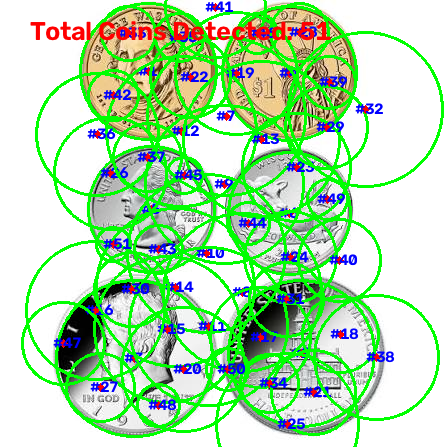

In [21]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Read input image
image = cv2.imread("/content/coins.jfif")
output = image.copy()

# 2. Convert to grayscale and apply Median Blur
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Increase median blur to smooth out the inner textures of the coins
blurred = cv2.medianBlur(gray, 9)

# 3. Perform Hough Circle Detection with tuned parameters
circles = cv2.HoughCircles(
    blurred,
    method=cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,      # Increased minimum distance between distinct coin centers
    param1=50,       # Upper threshold for Canny
    param2=50,       # Increased accumulator threshold to reduce false positives
    minRadius=20,     # Adjusted minimum expected coin radius
    maxRadius=120     # Adjusted maximum expected coin radius
)

# 4. Count and visualize detected coins
coin_count = 0

if circles is not None:
    # Round float circle specifications to integer pixel coordinates
    circles = np.uint16(np.around(circles))
    coin_count = len(circles[0])

    for i, circle in enumerate(circles[0, :]):
        x, y, r = circle[0], circle[1], circle[2]

        # Draw outer green circle boundary
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        # Draw small red dot at coin center
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

        # Label each individual coin with its index number
        cv2.putText(
            output,
            f"#{i+1}",
            (x - 10, y + 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2,
        )

# Overlay total coin count result on top of image
cv2.putText(
    output,
    f"Total Coins Detected: {coin_count}",
    (30, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 0, 255),
    2,
)

cv2_imshow(output)

(a) Otsu T = 194; naive contour count = 10 (touching coins form one blob)
(b) distance-fraction study
  fraction  markers  regions
      0.3       21       21
      0.5        8        8
      0.7        2        2
(c) Hough counts by param2: {15: 34, 25: 22, 35: 10} -> lower param2 = fewer votes needed = more (incl. false) circles
(d) per-coin table
  label  area    H     S     V  class
     2   922 17.9 110.1 187.3   gold
     3   766 18.2 111.8 196.8   gold
     4  1817 16.6 110.0 168.8   gold
     8  5667 42.4  27.1  79.6 silver
     9  2537  0.0   0.0  18.1 silver
(e) counts = {'gold': 3, 'silver': 2} -> TOTAL = Rs 40
    watershed count = 5, Hough (param2=25) = 22


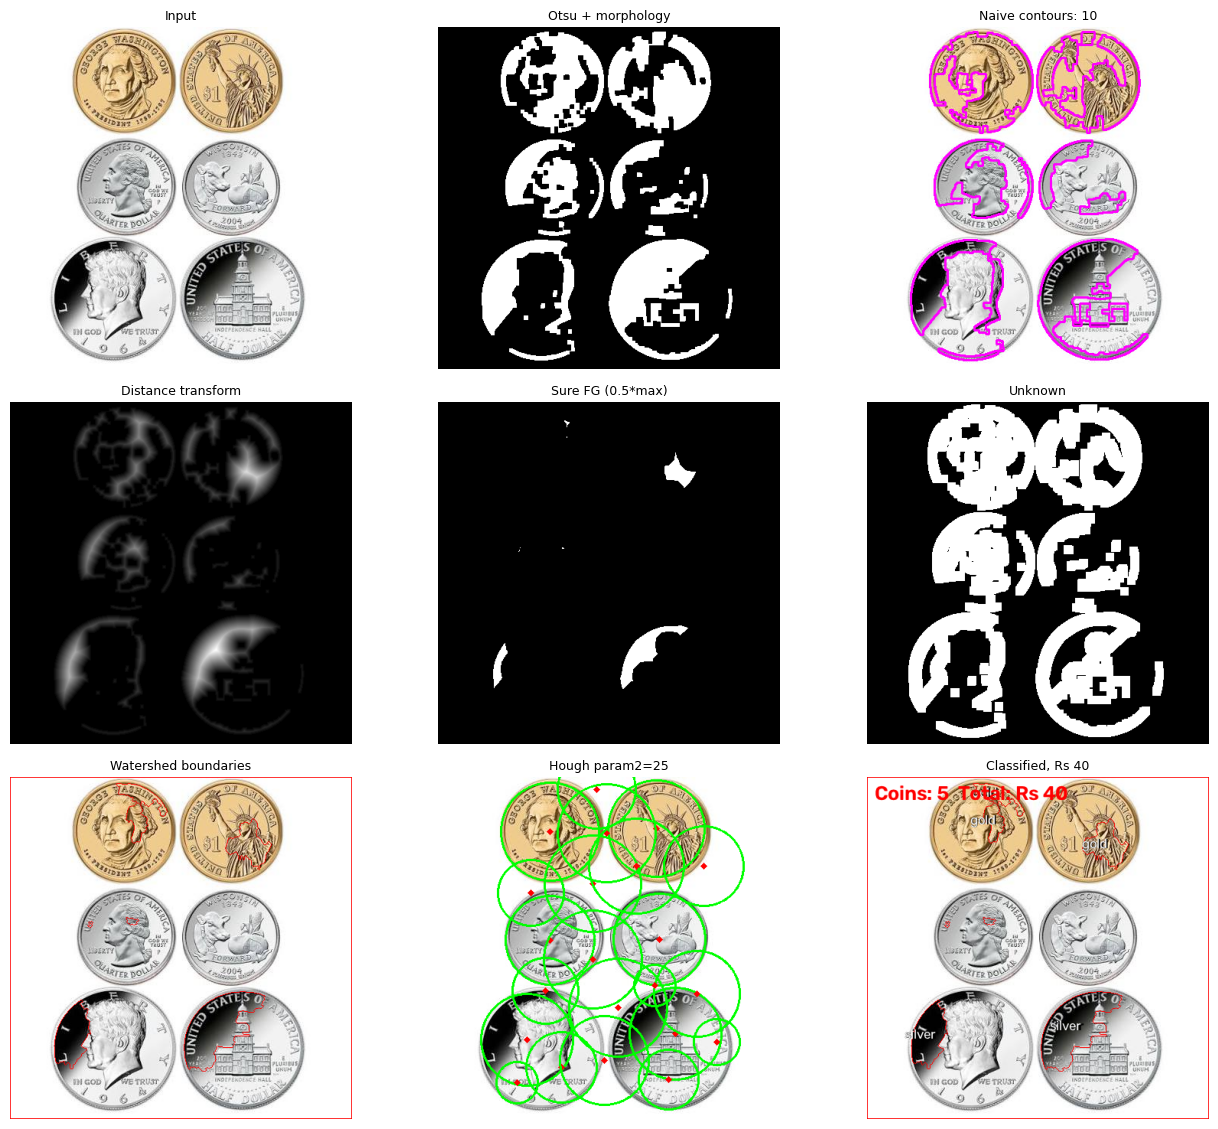

In [22]:
import cv2
import numpy as np

# 1. Load image and preprocess
image = cv2.imread("computer_lab.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# 2. Detect straight boundary lines using Probabilistic Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=80,
    minLineLength=50,
    maxLineGap=10,
)

# Create a blank mask and draw Hough lines to form continuous screen frames
line_mask = np.zeros_like(gray)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, 2)

# 3. Find rectangular screen boundaries formed by the Hough lines
contours, _ = cv2.findContours(
    line_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# Expected screen grid locations (x, y, w, h) for anomaly/missing screen detection
expected_screen_slots = [
    (50, 100, 150, 120),  # Seat 1
    (250, 100, 150, 120),  # Seat 2
    (450, 100, 150, 120),  # Seat 3
]

detected_screens = []

# 4. Filter contours and assess screen state (ON vs OFF)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h

    # Typical monitors have aspect ratios between 1.1 and 2.0 and a minimum size
    if 100 < w < 300 and 80 < h < 250 and 1.1 <= aspect_ratio <= 2.0:
        detected_screens.append((x, y, w, h))

        # Extract screen interior region from grayscale image
        screen_roi = gray[y : y + h, x : x + w]
        mean_brightness = np.mean(screen_roi)

        # Threshold to classify ON vs OFF screen status
        if mean_brightness > 80:
            status = "ON"
            color = (0, 255, 0)  # Green for active screen
        else:
            status = "OFF"
            color = (0, 255, 255)  # Yellow for turned off screen

        # Draw boundary and state tag
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(
            image,
            f"Screen: {status}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2,
        )

# 5. Anomaly Detection: Check for missing screens against expected lab slots
for slot_x, slot_y, slot_w, slot_h in expected_screen_slots:
    found = False
    for det_x, det_y, det_w, det_h in detected_screens:
        # Check if a detected screen overlaps with expected slot coordinates
        if (
            abs(slot_x - det_x) < 40
            and abs(slot_y - det_y) < 40
        ):
            found = True
            break

    if not found:
        # Flag missing screen anomaly
        cv2.rectangle(
            image,
            (slot_x, slot_y),
            (slot_x + slot_w, slot_y + slot_h),
            (0, 0, 255),
            2,
        )
        cv2.putText(
            image,
            "ANOMALY: MISSING",
            (slot_x, slot_y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 255),
            2,
        )

cv2.imshow("Lab Screen Monitoring", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np


def detect_road_lanes(image):
    height, width = image.shape[:2]

    # 1. Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    # 2. Define a Trapezoidal Region of Interest (ROI) covering the road ahead
    mask = np.zeros_like(edges)
    roi_polygon = np.array(
        [
            [
                (int(width * 0.1), height),
                (int(width * 0.45), int(height * 0.6)),
                (int(width * 0.55), int(height * 0.6)),
                (int(width * 0.9), height),
            ]
        ],
        dtype=np.int32,
    )

    cv2.fillPoly(mask, roi_polygon, 255)
    masked_edges = cv2.bitwise_and(edges, mask)

    # 3. Apply Hough Line Transform to isolate lane segments
    lines = cv2.HoughLinesP(
        masked_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=20,
        minLineLength=20,
        maxLineGap=100,
    )

    # 4. Draw lane lines on a blank layer
    lane_overlay = np.zeros_like(image)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Draw green lane markers
            cv2.line(lane_overlay, (x1, y1), (x2, y2), (0, 255, 0), 4)

    # 5. Blend overlay with the original camera frame
    final_output = cv2.addWeighted(image, 0.8, lane_overlay, 1.0, 0.0)
    return final_output


# Execute on an input image
frame = cv2.imread("road_lane.jpg")
result = detect_road_lanes(frame)

cv2.imshow("Autonomous Vehicle Lane Detection", result)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load query and train images
img1 = cv2.imread("object.jpg", cv2.IMREAD_GRAYSCALE)  # Query image
img2 = cv2.imread("scene.jpg", cv2.IMREAD_GRAYSCALE)  # Scene image

# 2. Instantiate SIFT detector
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute 128D descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# 4. Feature Matching using FLANN (Fast Library for Approximate Nearest Neighbors)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# 5. Apply Lowe's Ratio Test to eliminate false matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# 6. Draw matches
matched_img = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

# Display result
cv2.imshow("SIFT Feature Matching", matched_img)
cv2.waitKey(0)
cv2.destroyAllWindows()